<a href="https://colab.research.google.com/github/palarunava/machine-learning-courses/blob/main/udacity-intro-to-tf-for-dl/flowers_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

In [21]:
# _URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
IMG_WIDTH = 150
IMG_HEIGHT = 150

def resize_function(image, label):
  # Resize the image to the target size
  image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
  # Normalize the image to [0, 1] range
  image = tf.cast(image, tf.float32) / 255.0
  return image, label

ds, ds_info = tfds.load(
  'tf_flowers',
  split='train',
  with_info=True,
  as_supervised=True
)

# Apply the transformation to your tf.data.Dataset object
# Use num_parallel_calls for faster execution
ds = ds.map(
    resize_function,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [26]:
def display_images(ds, num_images=50):
  random_subset = ds.unbatch().shuffle(buffer_size=1000, seed=52).take(50)
  classes = ds_info.features['label'].names

  num_images_per_row = 5
  num_rows = num_images // num_images_per_row

  f, axarr = plt.subplots(num_rows, num_images_per_row, figsize=(15,20))

  i = j = 0
  for image, label in random_subset:
    axarr[i,j].imshow(image)
    axarr[i,j].set_title(f'{classes[label.numpy()]}', fontsize=10)
    axarr[i,j].axis('off')
    j += 1
    if j == num_images_per_row:
      i += 1
      j = 0

In [27]:
display_images(ds)

ValueError: Cannot unbatch an input with scalar components.

In [24]:
# Create a dedicated augmentation pipeline
data_augmentation = tf.keras.Sequential([
    # tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    # tf.keras.layers.RandomContrast(0.1)
])

AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

# Complete optimized pipeline
augmented_dataset = (
    ds
    # 1. CACHE first (saves raw, un-augmented images to RAM)
    .cache()

    # 2. SHUFFLE next (perfectly randomizes individual image order)
    .shuffle(buffer_size=ds.cardinality())

    # 3. BATCH third (groups the shuffled images into chunks)
    .batch(BATCH_SIZE)

    # 4. MAP augmentation (applies random flips/rotations to the entire batch)
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

    # 5. PREFETCH last (keeps the GPU fed constantly)
    .prefetch(buffer_size=AUTOTUNE)
)

TypeError: Invalid shape (32, 150, 150, 3) for image data

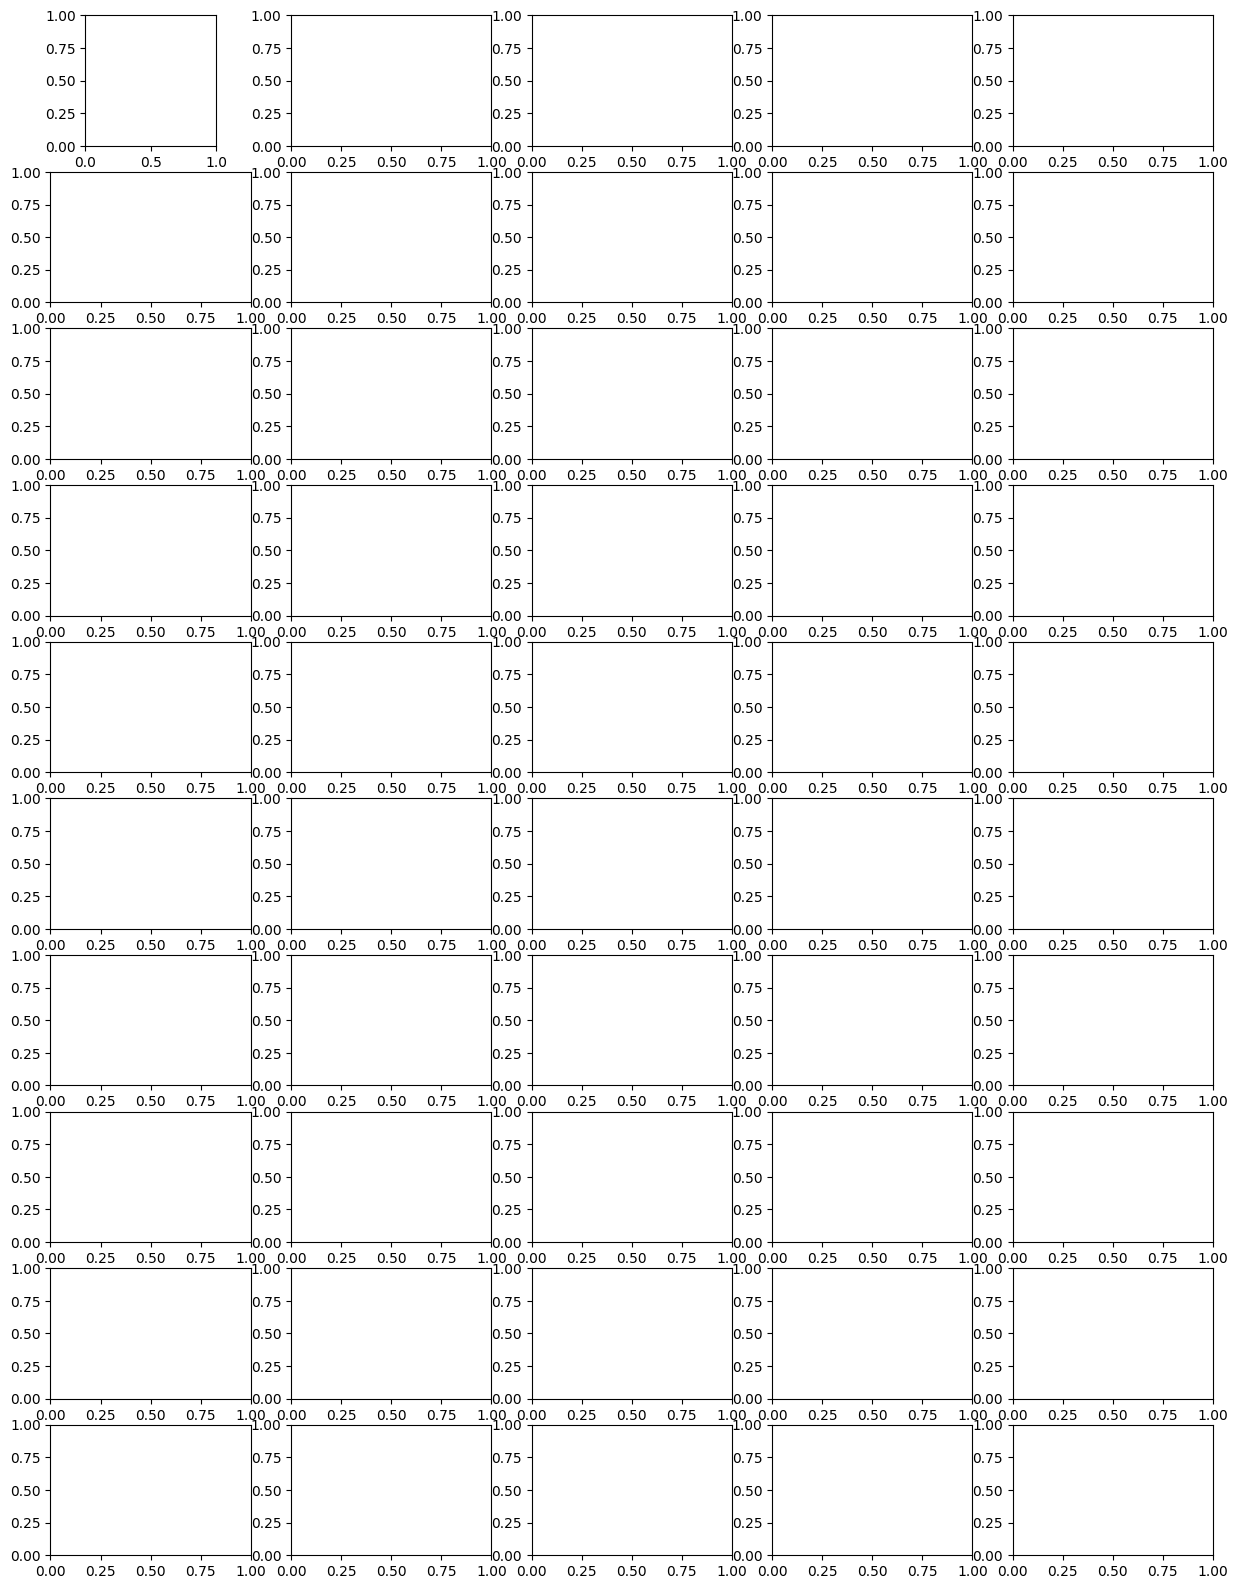

In [25]:
display_images(augmented_dataset)

In [28]:
ds

<_ParallelMapDataset element_spec=(TensorSpec(shape=(150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [29]:
augmented_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>